In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned dataset for time series analysis
df = pd.read_csv("../data/cleaned/ev_cleaned_for_time_series.csv")

df.head()

,region,year,EV_sales,sales_share,EV_stock,stock_share
0,Australia,2011,49.0,0.0065,49.0,0.00039
1,Australia,2012,125.0,0.0300,150.0,0.00240
2,Australia,2013,145.0,0.0340,295.0,0.00460
3,Australia,2014,660.0,0.1600,940.0,0.01400
4,Australia,2015,880.0,0.2000,1800.0,0.02700


In [16]:
# Aggregate global EV sales by year
ts_global = (
    df.groupby("year", as_index=False)["EV_sales"]
    .sum()
    .sort_values("year")
)

ts = ts_global["EV_sales"].values
years = ts_global["year"].values

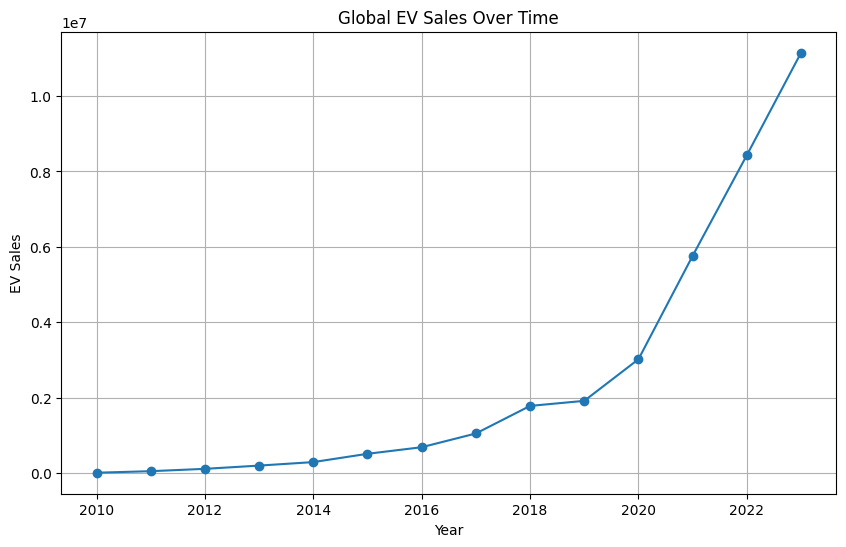

In [17]:
# Time series plot
plt.figure(figsize=(10,6))
plt.plot(years, ts, marker="o")
plt.title("Global EV Sales Over Time")
plt.xlabel("Year")
plt.ylabel("EV Sales")
plt.grid(True)
plt.show()

In [25]:
def difference(series, d):
    """Apply d-th order differencing to remove trend/non-stationarity."""
    diff = series.copy()
    for _ in range(d):
        diff = np.diff(diff)
    return diff

def undifference(last_vals, forecasts, d):
    """
    Invert differencing to recover original scale.
    last_vals: the last d values of each differencing level,
               stored during the forward differencing pass.
    """
    result = forecasts.copy()
    for level_last in reversed(last_vals):
        result = np.cumsum(np.append(level_last, result))[1:]
    return result

def build_lag_matrix(series, p):
    n = len(series)
    X = np.ones((n - p, p + 1))
    for i in range(1, p + 1):
        X[:, i] = series[p - i : n - i]
    y = series[p:]
    return X, y

def fit_ar_ols(series, p):
    """Fit AR(p) on the (differenced) series via OLS: beta = (X'X)^{-1} X'y"""
    X, y = build_lag_matrix(series, p)
    beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
    return beta

def compute_fitted_arima(series_orig, beta, p, d):
    """
    Compute in-sample fitted values in the original scale.
    Fits on differenced series, then inverts back.
    """
    series_diff = difference(series_orig, d)
    n_diff = len(series_diff)
    fitted_diff = np.full(n_diff, np.nan)
    for t in range(p, n_diff):
        lags = np.array([series_diff[t - i] for i in range(1, p + 1)])
        fitted_diff[t] = beta[0] + np.dot(beta[1:], lags)

    # Invert differencing for fitted values
    # Pad NaNs at front to align with original series length
    fitted_orig = np.full(len(series_orig), np.nan)
    for t in range(p, n_diff):
        # reconstruct one step at a time using true history
        partial = fitted_diff[t:t+1]
        last_vals = [series_orig[d - 1 + t - 1 : d - 1 + t]]  # simplified for d=1
        fitted_orig[d + t] = series_orig[d + t - 1] + partial[0]
    return fitted_orig, fitted_diff

def forecast_arima(series_orig, beta, p, d, steps):
    """
    Recursive ARIMA(p,d,0) forecast.
    1. Difference the series d times
    2. Forecast p steps ahead on the differenced series
    3. Invert differencing to recover original scale
    """
    series_diff = difference(series_orig, d)
    history_diff = list(series_diff)

    # Store last values needed to invert each differencing level
    last_vals = []
    temp = series_orig.copy()
    for _ in range(d):
        last_vals.append(temp[-1])
        temp = np.diff(temp)

    # Forecast on differenced series
    forecast_diff = []
    for _ in range(steps):
        lags = np.array([history_diff[-i] for i in range(1, p + 1)])
        next_val = beta[0] + np.dot(beta[1:], lags)
        forecast_diff.append(next_val)
        history_diff.append(next_val)

    # Invert differencing (d=1 case: cumsum from last observed value)
    forecast_orig = []
    prev = last_vals[0]
    for v in forecast_diff:
        prev = prev + v
        forecast_orig.append(prev)

    return forecast_orig, forecast_diff

# --- Fit ARIMA(1,1,0) ---
p, d = 1, 1
series_diff = difference(ts, d)
beta = fit_ar_ols(series_diff, p)
n_diff = len(series_diff)
X_fit, y_fit = build_lag_matrix(series_diff, p)
se = np.sqrt(np.diag(np.linalg.inv(X_fit.T @ X_fit) * np.mean((y_fit - X_fit @ beta)**2)))
z_vals = beta / se

print("=" * 60)
print(f"        ARIMA({p},{d},0) — Parameter Estimation Summary")
print("=" * 60)
print(f"  Method              : Manual OLS on {d}-st order differenced series")
print(f"  No. Observations    : {len(ts)} (original)  →  {n_diff} (after differencing)")
print(f"  AR lags (p)         : {p}")
print(f"  Differencing (d)    : {d}")
print(f"  No. params fitted   : {p + 1} (intercept + {p} AR coef)")
print("-" * 60)
print(f"  {'Parameter':<18} {'Estimate':>12} {'Std Err':>10} {'z-stat':>10}")
print("-" * 60)
labels = ["Intercept (c)"] + [f"phi_{i}" for i in range(1, p + 1)]
for label, b, s, z in zip(labels, beta, se, z_vals):
    print(f"  {label:<18} {b:>12.4f} {s:>10.4f} {z:>10.4f}")
print("=" * 60)
print("  Interpretation:")
print(f"    phi_1 = {beta[1]:.4f} → each differenced value carries")
print(f"    {beta[1]*100:.1f}% of the previous period's change forward.")
print(f"    Intercept = {beta[0]:,.2f} → average drift per year")
print(f"    in the differenced series (trend in growth rate).")
print("=" * 60)

        ARIMA(1,1,0) — Parameter Estimation Summary
  Method              : Manual OLS on 1-st order differenced series
  No. Observations    : 14 (original)  →  13 (after differencing)
  AR lags (p)         : 1
  Differencing (d)    : 1
  No. params fitted   : 2 (intercept + 1 AR coef)
------------------------------------------------------------
  Parameter              Estimate    Std Err     z-stat
------------------------------------------------------------
  Intercept (c)       241378.5194 196343.4733     1.2294
  phi_1                    0.9739     0.1666     5.8439
  Interpretation:
    phi_1 = 0.9739 → each differenced value carries
    97.4% of the previous period's change forward.
    Intercept = 241,378.52 → average drift per year
    in the differenced series (trend in growth rate).


In [26]:
# Fitted values on differenced series
X, y_diff = build_lag_matrix(series_diff, p)
fitted_diff = X @ beta
residuals = y_diff - fitted_diff

rmse = np.sqrt(np.mean(residuals ** 2))
mape = np.mean(np.abs(residuals / y_diff[y_diff != 0])) * 100

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y_diff - np.mean(y_diff)) ** 2)
r2 = 1 - ss_res / ss_tot
n_fit = len(y_diff)
k = p + 1
log_lik = -0.5 * n_fit * (np.log(2 * np.pi) + np.log(ss_res / n_fit) + 1)
aic = -2 * log_lik + 2 * k
bic = -2 * log_lik + k * np.log(n_fit)

print("=" * 60)
print(f"        ARIMA({p},{d},0) — In-Sample Fit Summary")
print("=" * 60)
print(f"  Fitted on           : differenced series ({n_fit} observations)")
print(f"  Residual std dev    : {np.std(residuals):>12,.2f}")
print(f"  RMSE                : {rmse:>12,.2f}")
print(f"  MAPE                : {mape:>11.2f}%")
print(f"  R²  (diff. series)  : {r2:>12.4f}")
print("-" * 60)
print(f"  Log-Likelihood      : {log_lik:>12.3f}")
print(f"  AIC                 : {aic:>12.3f}")
print(f"  BIC                 : {bic:>12.3f}")
print("=" * 60)
print("  Interpretation:")
print(f"    R² = {r2:.4f} → the AR({p}) term explains {r2*100:.1f}% of variance")
print(f"    in the differenced series.")
print(f"    Lower AIC/BIC = better model fit penalized for complexity.")
print(f"    RMSE is in differenced units (year-over-year change in EV sales).")
print("=" * 60)

        ARIMA(1,1,0) — In-Sample Fit Summary
  Fitted on           : differenced series (12 observations)
  Residual std dev    :   546,272.67
  RMSE                :   546,272.67
  MAPE                :      153.21%
  R²  (diff. series)  :       0.7400
--------------------------------------------------------------
  Log-Likelihood      :     -175.558
  AIC                 :      355.115
  BIC                 :      356.085
  Interpretation:
    R² = 0.7400 → the AR(1) term explains 74.0% of variance
    in the differenced series.
    Lower AIC/BIC = better model fit penalized for complexity.
    RMSE is in differenced units (year-over-year change in EV sales).


In [27]:
# Forecast for next 3 years
steps = 3
forecast_values, _ = forecast_arima(ts, beta, p, d, steps)
forecast_years = np.arange(years[-1] + 1, years[-1] + 1 + steps)
yoy_changes = np.diff(forecast_values)
growth_rates = [
    (forecast_values[0] - ts[-1]) / ts[-1] * 100
] + [(forecast_values[i] - forecast_values[i-1]) / forecast_values[i-1] * 100
     for i in range(1, steps)]

print("=" * 60)
print(f"        ARIMA({p},{d},0) — {steps}-Year Forecast Summary")
print("=" * 60)
print(f"  Last observed year  : {years[-1]}  ({ts[-1]:>12,.0f} EV sales)")
print("-" * 60)
print(f"  {'Year':<8} {'Forecast':>14} {'YoY Change':>13} {'Growth Rate':>13}")
print("-" * 60)
prev = ts[-1]
for yr, val, gr in zip(forecast_years, forecast_values, growth_rates):
    yoy = val - prev
    print(f"  {yr:<8} {val:>14,.0f} {yoy:>+13,.0f} {gr:>12.1f}%")
    prev = val
print("=" * 60)
print("  Interpretation:")
print(f"    The model projects EV sales will reach {forecast_values[-1]:,.0f}")
print(f"    by {forecast_years[-1]}, implying a cumulative growth of")
print(f"    {(forecast_values[-1] - ts[-1]) / ts[-1] * 100:.1f}% from {years[-1]}.")
print(f"    Forecasts assume the recent trend in annual growth")
print(f"    (captured by phi_1 = {beta[1]:.4f}) continues forward.")
print("=" * 60)

        ARIMA(1,1,0) — 3-Year Forecast Summary
  Last observed year  : 2023  (  11,148,348 EV sales)
------------------------------------------------------------
  Year           Forecast    YoY Change   Growth Rate
------------------------------------------------------------
  2024         14,035,797    +2,887,449         25.9%
  2025         17,089,164    +3,053,366         21.8%
  2026         20,304,111    +3,214,947         18.8%
  Interpretation:
    The model projects EV sales will reach 20,304,111
    by 2026, implying a cumulative growth of
    82.1% from 2023.
    Forecasts assume the recent trend in annual growth
    (captured by phi_1 = 0.9739) continues forward.


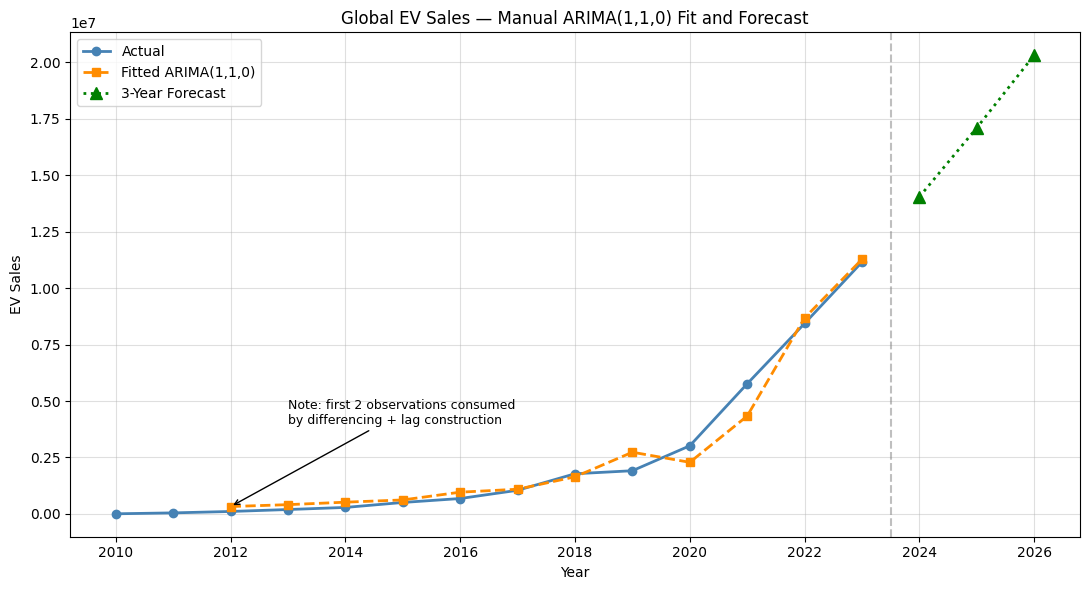

In [30]:
# Reconstruct fitted values in original scale (1-step-ahead)
fitted_orig = np.full(len(ts), np.nan)
for t in range(p, len(series_diff)):
    fitted_orig[t + d] = ts[t + d - 1] + (beta[0] + beta[1] * series_diff[t - 1])

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(years, ts, marker="o", label="Actual", color="steelblue", linewidth=2)
ax.plot(years, fitted_orig, marker="s", linestyle="--",
        label=f"Fitted ARIMA({p},{d},0)", color="darkorange", linewidth=2)
ax.plot(forecast_years, forecast_values, marker="^", linestyle=":",
        label=f"{steps}-Year Forecast", color="green", linewidth=2, markersize=9)

ax.axvline(x=years[-1] + 0.5, color="gray", linestyle="--", alpha=0.5)
ax.annotate(f"Note: first {p+d} observations consumed\nby differencing + lag construction",
            xy=(years[p+d], fitted_orig[p+d]), xytext=(2013, 4000000),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9, color="black")
ax.set_title(f"Global EV Sales — Manual ARIMA({p},{d},0) Fit and Forecast")
ax.set_xlabel("Year")
ax.set_ylabel("EV Sales")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()